# Loading and exploring the swaptions data

Quick notebook for hackathon participants to:
- load the train Excel file into pandas
- convert it to a PyTorch `Dataset`
- visualize the surface with a heatmap, a few time series, and evolution snapshots / GIF

In [57]:
# To access files stored in your Google Drive, you first need to mount your Drive to this Colab runtime.
# This typically involves authenticating with your Google account.
# You can click on the folder logo on the left or run
# from google.colab import drive
# drive.mount('/content/drive')
# it will open a window and you can accept

In [58]:
# useful importations
from pathlib import Path
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from lib.dataset import data as data_factory
from lib.model import build_model

torch.set_default_dtype(torch.float64)
torch.manual_seed(5)
np.random.seed(5)

DEVICE = torch.device("cpu")
DEVICE

device(type='cpu')

In [59]:
# navigating your repository
# PROJECT_ROOT = os.path.abspath("/content/drive/MyDrive/MilHaQ_Fest/Participants/Track2_QML")
PROJECT_ROOT = ""

DATA_PATH = os.path.join(PROJECT_ROOT, "data", "train.xlsx")
PLOTS_DIR = os.path.join(PROJECT_ROOT, "logs", "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Using project root: {PROJECT_ROOT}")
print(f"Train data path: {DATA_PATH}")
print(f"Plots will be saved to: {PLOTS_DIR}")

Using project root: 
Train data path: data\train.xlsx
Plots will be saved to: logs\plots


## Load the training data

In [60]:
from pointwise_swaptions import *

df = load_swaptions_excel(DATA_PATH)
samples, tenor_grid, maturity_grid = prepare_pointwise_dataset(df)

# inject_8_neighborhood(samples, tenor_grid, maturity_grid) # 8 Dimensional neighborhood
# inject_directional_differences(samples, tenor_grid, maturity_grid) # 4 Directional differences
inject_local_stats(samples, tenor_grid, maturity_grid) # 2 Local statistics: mean and std

print("Dataset size:", len(samples))
print(f"Features: {list(samples[0].keys())}")
print(f"Dates: {len(df['Date'].unique())}, Tenors : {len(tenor_grid)}, Maturities: {len(maturity_grid)}")
print(f"Tenors: {tenor_grid}")
print(f"Maturities: {maturity_grid}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

Dataset size: 110656
Features: ['date', 'tenor', 'maturity', 'vol', 'stats_2']
Dates: 494, Tenors : 14, Maturities: 16
Tenors: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 15.0, 20.0, 25.0, 30.0]
Maturities: [0.0833333333333333, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.0, 10.0, 15.0, 20.0, 25.0, 30.0]
Date range: 2050-01-01 → 2051-12-23


## Downsample (optional)

In [61]:
KEEP_TENORS = tenor_grid[:3]
KEEP_MATURITIES = maturity_grid[:3]
MAX_DATES = 50

# Filter samples by tenor/maturity
samples_small = [
    s for s in samples
    if s["tenor"] in KEEP_TENORS and s["maturity"] in KEEP_MATURITIES
]

# Filter by date (chronologically)
unique_dates = sorted({s["date"] for s in samples_small})
keep_dates = set(unique_dates[:MAX_DATES])

samples_small = [
    s for s in samples_small
    if s["date"] in keep_dates
]

print("Reduced dataset size:", len(samples_small))
print("Selected Tenors:", sorted({s["tenor"] for s in samples_small}))
print("Selected Maturities:", sorted({s["maturity"] for s in samples_small}))

print(f"Original Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Reduced Date range: {df['Date'][0].date()} → {df['Date'][MAX_DATES-1].date()}")

samples = samples_small

Reduced dataset size: 450
Selected Tenors: [1.0, 2.0, 3.0]
Selected Maturities: [0.0833333333333333, 0.25, 0.5]
Original Date range: 2050-01-01 → 2051-12-23
Reduced Date range: 2050-01-01 → 2050-03-13


## Build X and Y

In [62]:
# ============================================================
# Build a PyTorch Dataset from pointwise samples
# Target: next-day volatility at same (tenor, maturity)
# ============================================================

import torch
from torch.utils.data import Dataset

# ------------------------------------------------------------
# 1. Index samples by (date, tenor, maturity)
# ------------------------------------------------------------

sample_lookup = {}
for s in samples:
    key = (s["date"], s["tenor"], s["maturity"])
    sample_lookup[key] = s

# Sort unique dates
dates = sorted({s["date"] for s in samples})

# ------------------------------------------------------------
# 2. Build feature / target arrays
# ------------------------------------------------------------

X_list = []
y_list = []

for i in range(len(dates) - 1):
    date_t = dates[i]
    date_tp1 = dates[i + 1]

    for tenor in tenor_grid:
        for maturity in maturity_grid:
            key_t = (date_t, tenor, maturity)
            key_tp1 = (date_tp1, tenor, maturity)

            if key_t not in sample_lookup or key_tp1 not in sample_lookup:
                continue

            s_t = sample_lookup[key_t]
            s_tp1 = sample_lookup[key_tp1]

            # -------- FEATURES --------
            # [vol_t, tenor, maturity, mean_neighbors, std_neighbors]
            x = [
                s_t["vol"],
                s_t["tenor"],
                s_t["maturity"],
                s_t["stats_2"][0],
                s_t["stats_2"][1],
            ]

            # -------- TARGET --------
            y = s_tp1["vol"]

            X_list.append(x)
            y_list.append(y)

# Convert to tensors
X = torch.tensor(X_list, dtype=torch.float64)
y = torch.tensor(y_list, dtype=torch.float64).unsqueeze(1)

print(f"Dataset size: {len(X)} samples")
print(f"Input feature dim: {X.shape[1]}")
print(f"Target dim: {y.shape[1]}")


Dataset size: 441 samples
Input feature dim: 5
Target dim: 1


## Visualize the data

Saved logs\plots\time_series_pointwise.png


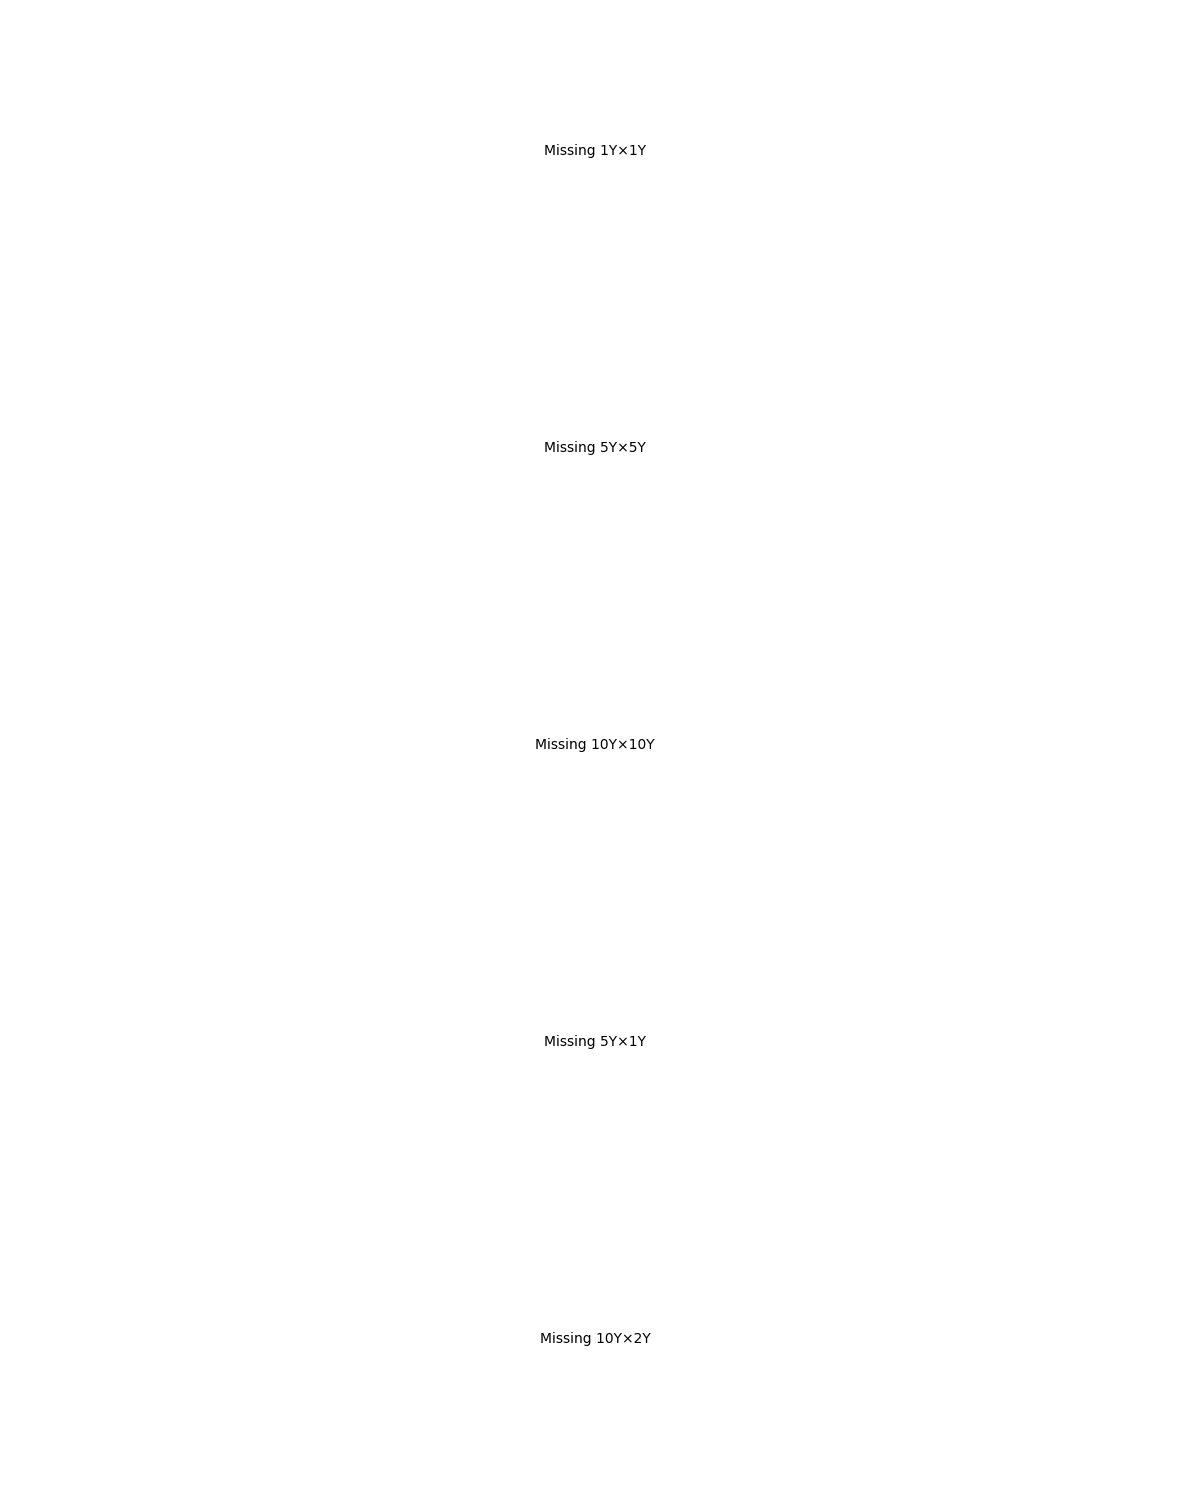

In [63]:
# ============================================================
# Visualize time series for selected (tenor, maturity) points
# ============================================================

import matplotlib.pyplot as plt
import os
from collections import defaultdict

# ------------------------------------------------------------
# Define key strikes (tenor, maturity, label)
# ------------------------------------------------------------

key_strikes = [
    (1.0, 1.0, '1Y×1Y'),
    (5.0, 5.0, '5Y×5Y'),
    (10.0, 10.0, '10Y×10Y'),
    (5.0, 1.0, '5Y×1Y'),
    (10.0, 2.0, '10Y×2Y'),
]

# ------------------------------------------------------------
# Index samples by (tenor, maturity)
# ------------------------------------------------------------

series_map = defaultdict(list)
for s in samples:
    series_map[(s["tenor"], s["maturity"])].append((s["date"], s["vol"]))

# Sort each time series by date
for k in series_map:
    series_map[k].sort(key=lambda x: x[0])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(key_strikes),
    1,
    figsize=(12, 3 * len(key_strikes)),
    sharex=True
)

for ax, (tenor, maturity, label) in zip(axes, key_strikes):
    key = (tenor, maturity)

    if key not in series_map:
        ax.text(0.5, 0.5, f"Missing {label}", ha="center", va="center")
        ax.set_axis_off()
        continue

    dates, vols = zip(*series_map[key])
    ax.plot(dates, vols)
    ax.set_ylabel("Vol")
    ax.legend([label], loc="upper right")

axes[-1].set_xlabel("Date")
plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

time_series_path = os.path.join(PLOTS_DIR, "time_series_pointwise.png")
fig.savefig(time_series_path, dpi=200)
print(f"Saved {time_series_path}")

plt.show()


# Build dataset

## Configuration

In [64]:
# ============================================================
# Build QLSTM sequences and split into train / val / test
# ============================================================

import numpy as np
import torch
from collections import defaultdict

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SEQ_LEN = 5 # sequence length for QLSTM
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

## Build sequence window

In [65]:
# ------------------------------------------------------------
# Feature selector
# ------------------------------------------------------------
# Must match what you injected earlier
# Current features:
#   [vol, tenor, maturity, mean_neighbors, std_neighbors]

def extract_features(sample):
    return [
        sample["vol"],
        sample["tenor"],
        sample["maturity"],
        sample["stats_2"][0],
        sample["stats_2"][1],
    ]


# ------------------------------------------------------------
# Group samples by (tenor, maturity)
# ------------------------------------------------------------

series_map = defaultdict(list)
for s in samples:
    series_map[(s["tenor"], s["maturity"])].append(s)

# Sort each series by date
for key in series_map:
    series_map[key].sort(key=lambda s: s["date"])


# ------------------------------------------------------------
# Build sequences
# ------------------------------------------------------------

X_all = []
y_all = []
date_all = []  # for chronological split

for (tenor, maturity), series in series_map.items():
    if len(series) <= SEQ_LEN:
        continue

    for i in range(len(series) - SEQ_LEN):
        seq = series[i : i + SEQ_LEN]
        target = series[i + SEQ_LEN]

        X_all.append([extract_features(s) for s in seq])
        y_all.append(target["vol"])
        date_all.append(target["date"])

# Convert to tensors
X_all = torch.tensor(X_all, dtype=torch.float64)  # (N, T, input_size)
y_all = torch.tensor(y_all, dtype=torch.float64).unsqueeze(1)  # (N, 1)

print(f"Total sequences: {len(X_all)}")
print(f"X shape: {X_all.shape}")
print(f"y shape: {y_all.shape}")

Total sequences: 405
X shape: torch.Size([405, 5, 5])
y shape: torch.Size([405, 1])


## Split the dataset into train/val/test

In [66]:
# Sort by target date to avoid leakage
order = torch.argsort(torch.tensor(date_all, dtype=torch.int64))
X_all = X_all[order]
y_all = y_all[order]

N = len(X_all)
n_train = int(TRAIN_RATIO * N)
n_val = int(VAL_RATIO * N)

X_train = X_all[:n_train]
y_train = y_all[:n_train]

X_val = X_all[n_train : n_train + n_val]
y_val = y_all[n_train : n_train + n_val]

X_test = X_all[n_train + n_val :]
y_test = y_all[n_train + n_val :]

print("Split sizes:")
print(f"  Train: {len(X_train)}")
print(f"  Val  : {len(X_val)}")
print(f"  Test : {len(X_test)}")

Split sizes:
  Train: 283
  Val  : 60
  Test : 62


## Scaling the sets

In [67]:
# ============================================================
# Feature scaling (train-only fit, no leakage)
# ============================================================

from sklearn.preprocessing import StandardScaler
import numpy as np

# ------------------------------------------------------------
# Identify feature indices
# ------------------------------------------------------------
# X shape: (N, T, F)
VOL_IDX = 0
TENOR_IDX = 1
MAT_IDX = 2
MEAN_IDX = 3
STD_IDX = 4

# ------------------------------------------------------------
# 1. Scale stochastic features with StandardScaler
# ------------------------------------------------------------

scaler = StandardScaler()

# Fit on TRAIN ONLY (flatten time dimension)
X_train_flat = X_train[:, :, [VOL_IDX, MEAN_IDX, STD_IDX]].reshape(-1, 3)
scaler.fit(X_train_flat)

def apply_scaler(X):
    X = X.clone()
    flat = X[:, :, [VOL_IDX, MEAN_IDX, STD_IDX]].reshape(-1, 3)
    scaled = scaler.transform(flat)
    X[:, :, [VOL_IDX, MEAN_IDX, STD_IDX]] = torch.tensor(
        scaled.reshape(X.shape[0], X.shape[1], 3),
        dtype=X.dtype,
    )
    return X

X_train = apply_scaler(X_train)
X_val = apply_scaler(X_val)
X_test = apply_scaler(X_test)

# ------------------------------------------------------------
# 2. Scale tenor and maturity to [0, 1]
# ------------------------------------------------------------

max_tenor = max(tenor_grid)
max_maturity = max(maturity_grid)

for X in (X_train, X_val, X_test):
    X[:, :, TENOR_IDX] /= max_tenor
    X[:, :, MAT_IDX] /= max_maturity

# ------------------------------------------------------------
# 3. Scale target volatility (train-only)
# ------------------------------------------------------------

y_scaler = StandardScaler()
y_scaler.fit(y_train)

y_train = torch.tensor(y_scaler.transform(y_train), dtype=torch.float64)
y_val = torch.tensor(y_scaler.transform(y_val), dtype=torch.float64)
y_test = torch.tensor(y_scaler.transform(y_test), dtype=torch.float64)

print("Scaling complete.")
print("Train mean (vol):", X_train[:, :, VOL_IDX].mean().item())
print("Train std  (vol):", X_train[:, :, VOL_IDX].std().item())


Scaling complete.
Train mean (vol): 1.4869927040774534e-15
Train std  (vol): 1.0003535442924691


## Photonic QLSTM

`PhotonicQLSTMCell` glues four photonic VQCs into the usual LSTM gating equations:

1. **Encoding.** At each time step we concatenate the current value and hidden state (`n_v = input + hidden`). Those amplitudes are encoded into a `2 n_v`-mode interferometer (beam splitters + phase shifters) built with Perceval.
2. **Trainable interferometers.** MerLin wraps that circuit into differentiable `QuantumLayer`s whose parameters \(	heta\) are optimized via PyTorch autograd.
3. **Classical view.** Measurement strategies (mode expectations by default) map the photonic state back to a real vector, which drives the standard LSTM update equations. An optional photonic head can replace the final linear projection, but we keep the classical head for speed.

With this setup, swapping a classical LSTM for a photonic one is only a matter of changing `model_type` when calling `build_model`.


In [68]:
HIDDEN_SIZE = 3
SHOTS = 0  # 0 = exact expectations, >0 would sample the interferometer

model = (
    build_model(
        model_type="qlstm_photonic",
        input_size=X_train.shape[2],
        hidden_size=HIDDEN_SIZE,
        vqc_depth=0,  # unused for photonic cell, kept for API parity
        output_size=1,
        shots=SHOTS,
        use_photonic_head=False,
    )
    .to(DEVICE)
    .double()
)

model

SequenceModel(
  (cell): PhotonicQLSTMCell(
    (vqc_i): MerlinPhotonicGate(
      (quantum_layer): QuantumLayer(
        (_photon_loss_transform): PhotonLossTransform()
        (_detector_transform): DetectorTransform()
        (measurement_mapping): ModeExpectations()
      )
      (post): Linear(in_features=16, out_features=3, bias=True)
    )
    (vqc_f): MerlinPhotonicGate(
      (quantum_layer): QuantumLayer(
        (_photon_loss_transform): PhotonLossTransform()
        (_detector_transform): DetectorTransform()
        (measurement_mapping): ModeExpectations()
      )
      (post): Linear(in_features=16, out_features=3, bias=True)
    )
    (vqc_g): MerlinPhotonicGate(
      (quantum_layer): QuantumLayer(
        (_photon_loss_transform): PhotonLossTransform()
        (_detector_transform): DetectorTransform()
        (measurement_mapping): ModeExpectations()
      )
      (post): Linear(in_features=16, out_features=3, bias=True)
    )
    (vqc_o): MerlinPhotonicGate(
      (q

# Training Loop

## Configuration

In [69]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import time

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 5e-3

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

print(f"Train batches: {len(train_loader)}")

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Validation batches: {len(val_loader)}")

# ------------------------------------------------------------
# Optimizer & loss
# ------------------------------------------------------------

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

Train batches: 18
Validation batches: 4


In [71]:
from tqdm import tqdm

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    # ----------------------
    # Train
    # ----------------------
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        pred_seq, _ = model(xb) # pred: (B, T, 1)
        pred = pred_seq[:, -1, :] # Take last time step (B, 1)
        loss = criterion(pred, yb) # yb: (B, 1)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # ----------------------
    # Validate
    # ----------------------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred_seq, _ = model(xb) # pred: (B, T, 1)
            pred = pred_seq[:, -1, :] # Take last time step (B, 1)
            loss = criterion(pred, yb) # yb: (B, 1)
            val_loss += loss.item() * xb.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    # ----------------------
    # Logging
    # ----------------------
    print(
        f"Epoch {epoch:03d} | "
        f"Train MSE: {train_loss:.6f} | "
        f"Val MSE: {val_loss:.6f}"
    )

elapsed = time.time() - start_time
print(f"Training finished in {elapsed/60:.1f} minutes")


Epoch 001 | Train MSE: 0.867813 | Val MSE: 0.723792
Epoch 002 | Train MSE: 0.453783 | Val MSE: 0.205889
Epoch 003 | Train MSE: 0.091425 | Val MSE: 0.047404
Epoch 004 | Train MSE: 0.038591 | Val MSE: 0.035736
Epoch 005 | Train MSE: 0.031901 | Val MSE: 0.030376
Epoch 006 | Train MSE: 0.028223 | Val MSE: 0.027894
Epoch 007 | Train MSE: 0.026478 | Val MSE: 0.022611
Epoch 008 | Train MSE: 0.023894 | Val MSE: 0.018935
Epoch 009 | Train MSE: 0.023232 | Val MSE: 0.016072
Epoch 010 | Train MSE: 0.021842 | Val MSE: 0.013571
Training finished in 27.2 minutes


Photonic test MSE (original scale): 1.695911e-05


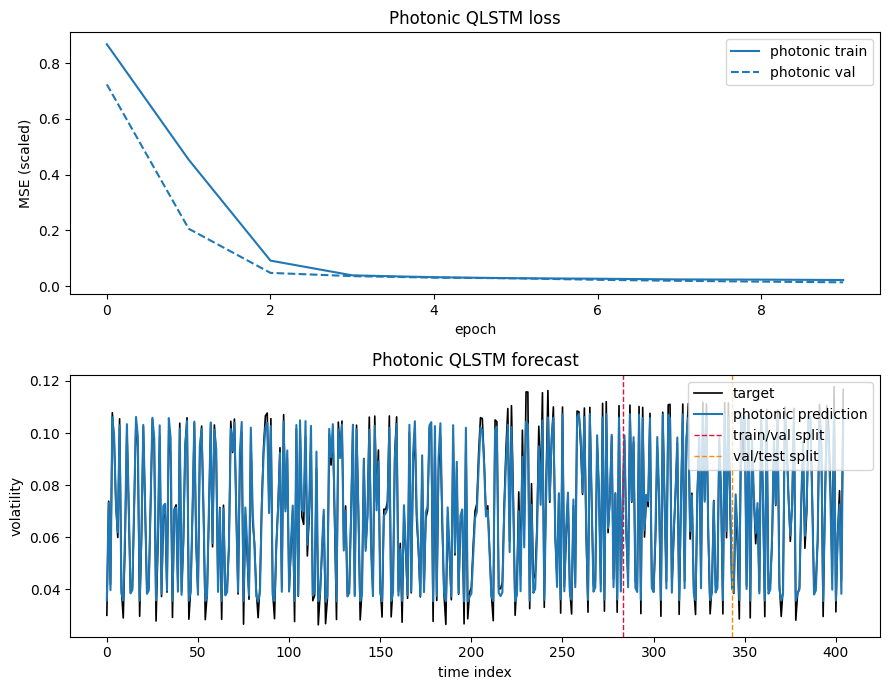

In [ ]:
# ============================================================
# Final test evaluation + plotting
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch

# ------------------------------------------------------------
# 1. Evaluate photonic model on TEST set
# ------------------------------------------------------------

model.eval()
with torch.no_grad():
    pred_seq_test, _ = model(X_test)
    y_pred_test = pred_seq_test[:, -1, :]  # (N_test, 1)

# Inverse scaling
y_test_np = y_scaler.inverse_transform(y_test.cpu().numpy()).flatten()
y_pred_test_np = y_scaler.inverse_transform(y_pred_test.cpu().numpy()).flatten()

# Test MSE (in original units)
test_mse = np.mean((y_pred_test_np - y_test_np) ** 2)
print(f"Photonic test MSE (original scale): {test_mse:.6e}")

# ------------------------------------------------------------
# 2. Build full prediction curve (train + val + test)
# ------------------------------------------------------------

def predict_all(model, X):
    model.eval()
    with torch.no_grad():
        seq, _ = model(X)
        return seq[:, -1, :]

# Predict everywhere
y_pred_train = predict_all(model, X_train)
y_pred_val = predict_all(model, X_val)
y_pred_test = predict_all(model, X_test)

# Concatenate (scaled)
y_pred_all_scaled = torch.cat(
    [y_pred_train, y_pred_val, y_pred_test], dim=0
).cpu().numpy()

y_all_scaled = torch.cat(
    [y_train, y_val, y_test], dim=0
).cpu().numpy()

# Inverse transform
y_pred_all = y_scaler.inverse_transform(y_pred_all_scaled).flatten()
y_all_true = y_scaler.inverse_transform(y_all_scaled).flatten()

# ------------------------------------------------------------
# 3. Loss history container (photonic only)
# ------------------------------------------------------------

photonic_history = {
    "train": train_losses,
    "val": val_losses,
}


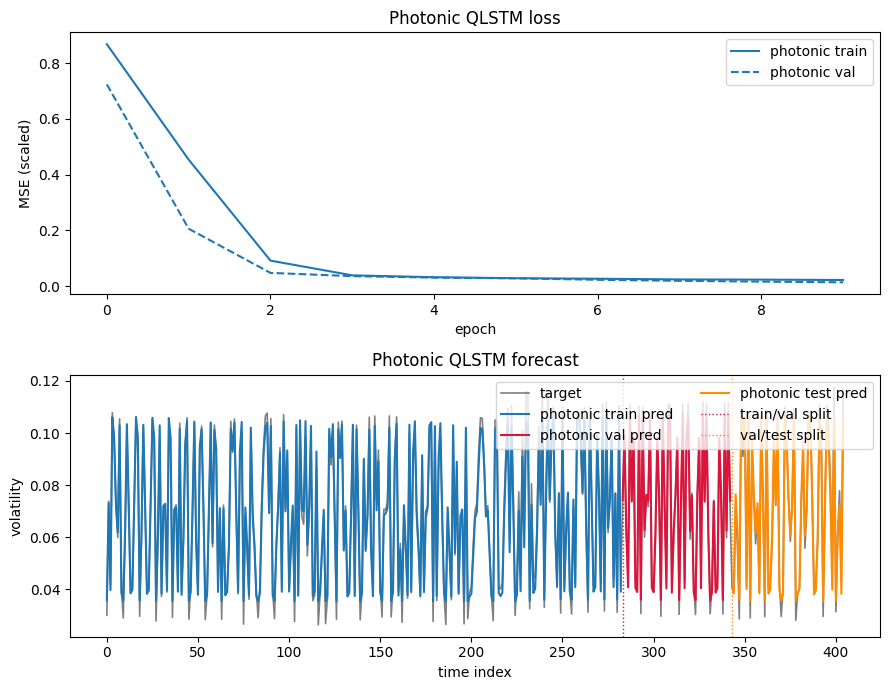

In [75]:
# ------------------------------------------------------------
# 4. Plot loss + prediction curves (styled)
# ------------------------------------------------------------

fig, (ax_loss, ax_pred) = plt.subplots(2, 1, figsize=(9, 7))

# ---- Loss curves ----
ax_loss.plot(photonic_history["train"], label="photonic train", color="tab:blue")
ax_loss.plot(photonic_history["val"], label="photonic val", color="tab:blue", ls="--")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("MSE (scaled)")
ax_loss.set_title("Photonic QLSTM loss")
ax_loss.legend()

# ---- Prediction curves ----
time_idx = np.arange(len(y_all_true))
split_train = len(y_train)
split_val = split_train + len(y_val)

# Target (lighter)
ax_pred.plot(
    time_idx,
    y_all_true,
    label="target",
    color="black",
    lw=1.2,
    alpha=0.5,
)

# Train predictions (blue, dashed)
ax_pred.plot(
    time_idx[:split_train],
    y_pred_all[:split_train],
    label="photonic train pred",
    color="tab:blue",
)

# Val predictions (red, dashed)
ax_pred.plot(
    time_idx[split_train:split_val],
    y_pred_all[split_train:split_val],
    label="photonic val pred",
    color="crimson",
)

# Test predictions (orange, dashed)
ax_pred.plot(
    time_idx[split_val:],
    y_pred_all[split_val:],
    label="photonic test pred",
    color="darkorange",
)

# Split markers
ax_pred.axvline(split_train, color="crimson", ls=":", lw=1, label="train/val split")
ax_pred.axvline(split_val, color="darkorange", ls=":", lw=1, label="val/test split")

ax_pred.set_xlabel("time index")
ax_pred.set_ylabel("volatility")
ax_pred.set_title("Photonic QLSTM forecast")
ax_pred.legend(loc="upper right", ncol=2)

plt.tight_layout()
plt.show()


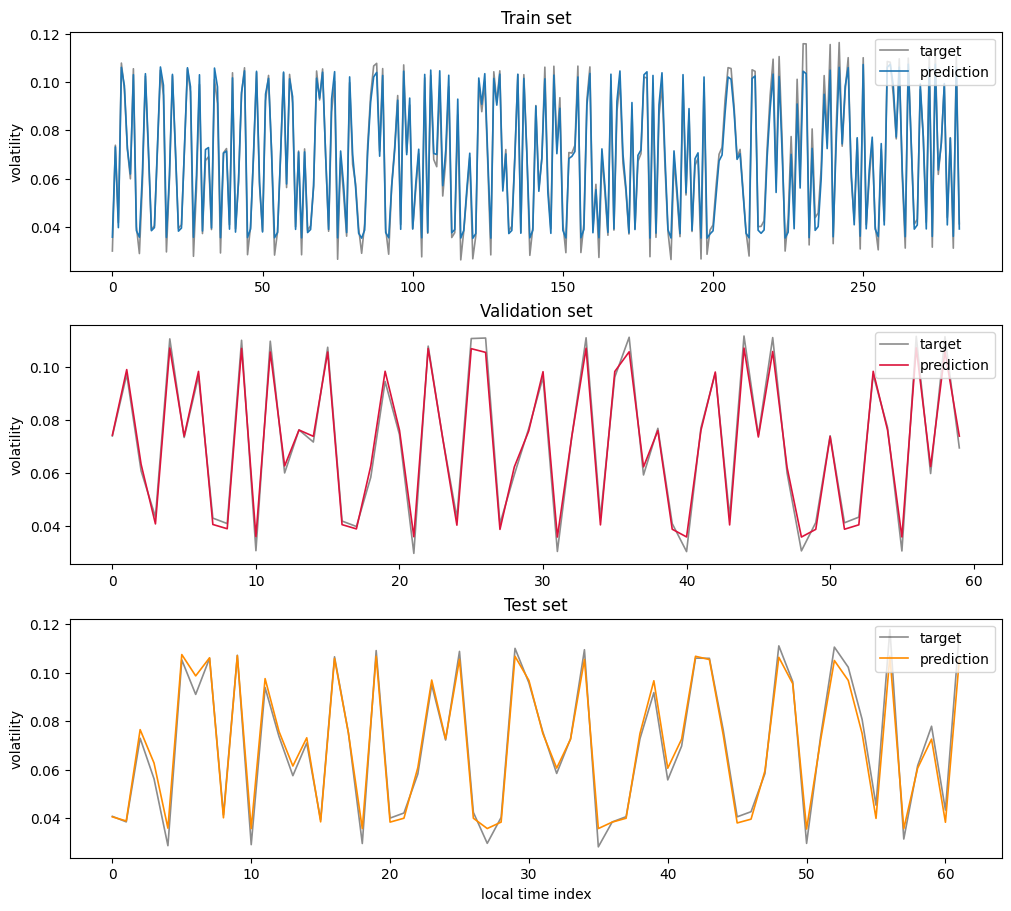

In [78]:
# ------------------------------------------------------------
# Stacked prediction plots with local x-axes
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 9),
    sharex=False,
    constrained_layout=True
)

# Split sizes
n_train = len(y_train)
n_val = len(y_val)
n_test = len(y_test)

# ============================================================
# Train
# ============================================================

ax = axes[0]
t_train = np.arange(n_train)

ax.plot(
    t_train,
    y_all_true[:n_train],
    color="black",
    alpha=0.45,
    lw=1.2,
    label="target",
)
ax.plot(
    t_train,
    y_pred_all[:n_train],
    color="tab:blue",
    lw=1.2,
    label="prediction",
)

ax.set_title("Train set")
ax.set_ylabel("volatility")
ax.legend(loc="upper right")

# ============================================================
# Validation
# ============================================================

ax = axes[1]
t_val = np.arange(n_val)

ax.plot(
    t_val,
    y_all_true[n_train : n_train + n_val],
    color="black",
    alpha=0.45,
    lw=1.2,
    label="target",
)
ax.plot(
    t_val,
    y_pred_all[n_train : n_train + n_val],
    color="crimson",
    lw=1.2,
    label="prediction",
)

ax.set_title("Validation set")
ax.set_ylabel("volatility")
ax.legend(loc="upper right")

# ============================================================
# Test
# ============================================================

ax = axes[2]
t_test = np.arange(n_test)

ax.plot(
    t_test,
    y_all_true[n_train + n_val :],
    color="black",
    alpha=0.45,
    lw=1.2,
    label="target",
)
ax.plot(
    t_test,
    y_pred_all[n_train + n_val :],
    color="darkorange",
    lw=1.2,
    label="prediction",
)

ax.set_title("Test set")
ax.set_xlabel("local time index")
ax.set_ylabel("volatility")
ax.legend(loc="upper right")

plt.show()